# Basis Blended Tokens — MIMIC AUCs

End-to-end validation of the basis blended tokens method (see `fuzzy_token_planning.md`): a model trained on MIMIC-2.1.0 (tokenized by `new_cocoa` with `n_bins=10`, `fused=true`, `include_exact_rank=true`), representations extracted with `cotorra extract`, and scored with `cotorra rep-based-score` against the outcome tokens defined in `new_cocoa`'s winnowing config.

This notebook reads the `scores-rep-based-*.parquet` output and reports ROC-AUC (with bootstrap confidence intervals) per outcome.

In [1]:
import pathlib

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from cotorra.util import bootstrap_ci

PROCESSED = pathlib.Path.home() / "new_cocoa/cocoa/processed_basis_blended"
MODEL_NAME = "mdl-basis-blended-mimic"

scores_path = PROCESSED / f"scores-rep-based-{MODEL_NAME}.parquet"
df = pl.read_parquet(scores_path)
print(df.shape)
df.select(pl.col("^.*_rep_score$")).columns

(97461, 62)


['ASMT//cam_total_yes_rep_score',
 'DSCG//expired_rep_score',
 'LABEL//anemia_init_rep_score',
 'LABEL//crrt_init_rep_score',
 'LABEL//hyperk_init_rep_score',
 'LABEL//hyperna_init_rep_score',
 'LABEL//hypertension_init_rep_score',
 'LABEL//hypok_init_rep_score',
 'LABEL//hypona_init_rep_score',
 'LABEL//hypotension_init_rep_score',
 'LABEL//pressor_init_rep_score',
 'LABEL//sepsis_onset_rep_score',
 'LABEL//tachy_init_rep_score',
 'RESP//imv_rep_score',
 'XFR-IN//icu_rep_score']

In [2]:
score_cols = [c for c in df.columns if c.endswith("_rep_score")]

results = []
for score_col in score_cols:
    token = score_col[: -len("_rep_score")]
    past_col, future_col = f"{token}_past", f"{token}_future"

    sub = df.select(~pl.col(past_col), pl.col(future_col), pl.col(score_col)).drop_nulls()
    y_true = sub[future_col].to_numpy().astype(int)
    y_score = sub[score_col].to_numpy()
    finite = np.isfinite(y_score)
    y_true, y_score = y_true[finite], y_score[finite]

    n_pos, n = int(y_true.sum()), len(y_true)
    if n_pos == 0 or n_pos == n or n < 10:
        print(f"skipping {token}: n={n}, n_pos={n_pos} (degenerate for AUC)")
        continue

    auc = roc_auc_score(y_true, y_score)
    ci = bootstrap_ci(y_true, y_score, metrics=("roc_auc",), n_samples=2000)["roc_auc"]
    results.append(
        {"token": token, "auc": auc, "ci_lo": ci[0], "ci_hi": ci[1], "n": n, "n_pos": n_pos}
    )

res = pl.DataFrame(results).sort("auc", descending=True)
res

token,auc,ci_lo,ci_hi,n,n_pos
str,f64,f64,f64,i64,i64
"""LABEL//crrt_init""",0.902275,0.887734,0.915919,97350,466
"""LABEL//hypertension_init""",0.883829,0.877071,0.889838,95816,3026
"""LABEL//hyperna_init""",0.879865,0.838925,0.916584,97374,109
"""LABEL//tachy_init""",0.871097,0.863441,0.878557,96320,2250
"""ASMT//cam_total_yes""",0.868296,0.860901,0.875745,95722,2600
…,…,…,…,…,…
"""LABEL//hypona_init""",0.780506,0.752476,0.807743,97233,226
"""XFR-IN//icu""",0.778477,0.771216,0.785444,84178,3567
"""LABEL//anemia_init""",0.77731,0.770518,0.783914,95308,4127


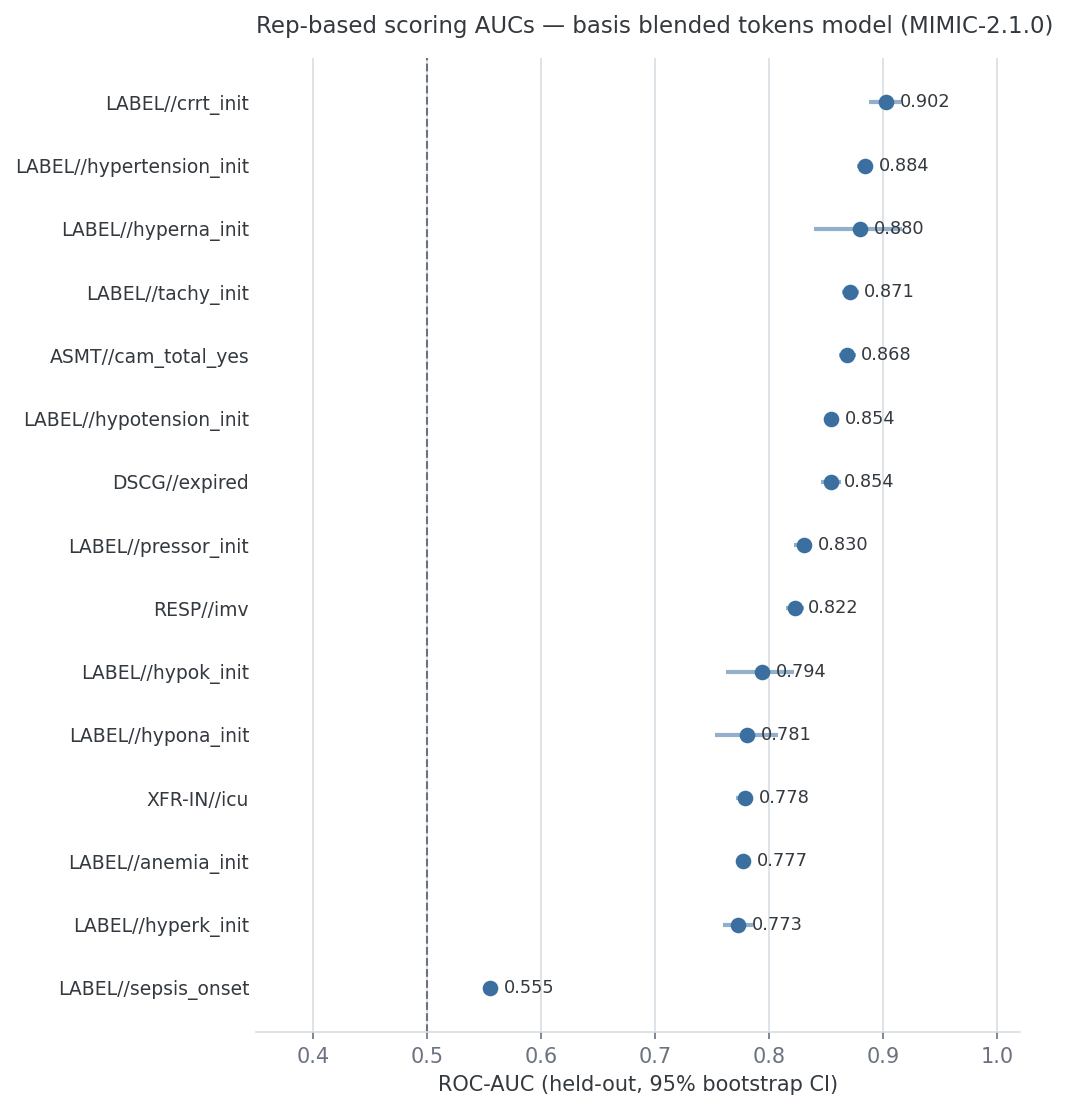

In [3]:
# single-hue, single-series magnitude chart: horizontal dot plot sorted by AUC,
# bootstrap 95% CI whiskers, chance-level (0.5) reference line, direct value labels
MARK_COLOR = "#3B6FA0"
GRID_COLOR = "#D8DEE4"
TEXT_COLOR = "#33393F"
MUTED_COLOR = "#6B7280"

labels = res["token"].to_list()
aucs = res["auc"].to_numpy()
lo = res["ci_lo"].to_numpy()
hi = res["ci_hi"].to_numpy()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(7, 0.4 * len(labels) + 1.5), dpi=150)

ax.axvline(0.5, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.hlines(y, lo, hi, color=MARK_COLOR, linewidth=2, alpha=0.55, zorder=2)
ax.scatter(aucs, y, s=42, color=MARK_COLOR, zorder=3)

for yi, auc in zip(y, aucs):
    ax.text(auc + 0.012, yi, f"{auc:.3f}", va="center", fontsize=8.5, color=TEXT_COLOR)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
ax.set_xlabel("ROC-AUC (held-out, 95% bootstrap CI)", fontsize=10, color=TEXT_COLOR)
ax.set_xlim(0.35, 1.02)

for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    "Rep-based scoring AUCs — basis blended tokens model (MIMIC-2.1.0)",
    fontsize=11,
    color=TEXT_COLOR,
    loc="left",
    pad=12,
)

fig.tight_layout()
fig.savefig("auc_by_outcome.png", bbox_inches="tight")
plt.show()

## Baseline comparison: basis blended tokens vs. standard NTP

To tell whether the basis blended tokens method is actually helping, we need
a baseline: a model trained on the *identical* processed data, with the
*identical* architecture, `max_seq_len`, batch size, learning rate, and
number of steps (3000, ~0.67 epochs) -- the only difference is that
`basis_blended_tokens` is disabled, so numeric measurements are represented
the standard way (one fused decile token per value) and trained with plain
next-token-prediction cross-entropy (see `../baseline_mimic/`).

Both models' `rep-based-score` outputs are loaded and compared per outcome
below.

In [4]:
def compute_aucs(model_name: str) -> pl.DataFrame:
    scores = pl.read_parquet(PROCESSED / f"scores-rep-based-{model_name}.parquet")
    out = []
    for score_col in [c for c in scores.columns if c.endswith("_rep_score")]:
        token = score_col[: -len("_rep_score")]
        past_col, future_col = f"{token}_past", f"{token}_future"
        sub = scores.select(
            ~pl.col(past_col), pl.col(future_col), pl.col(score_col)
        ).drop_nulls()
        y_true = sub[future_col].to_numpy().astype(int)
        y_score = sub[score_col].to_numpy()
        finite = np.isfinite(y_score)
        y_true, y_score = y_true[finite], y_score[finite]
        n_pos, n = int(y_true.sum()), len(y_true)
        if n_pos == 0 or n_pos == n or n < 10:
            continue
        auc = roc_auc_score(y_true, y_score)
        ci = bootstrap_ci(y_true, y_score, metrics=("roc_auc",), n_samples=2000)["roc_auc"]
        out.append({"token": token, "auc": auc, "ci_lo": ci[0], "ci_hi": ci[1]})
    return pl.DataFrame(out)


BASELINE_MODEL_NAME = "mdl-baseline-mimic"
res_basis = compute_aucs(MODEL_NAME)
res_baseline = compute_aucs(BASELINE_MODEL_NAME)

AUC_FLOOR = 0.55  # drop outcomes neither model actually learned (near-chance for both)
cmp_all = (
    res_basis.rename({"auc": "auc_basis", "ci_lo": "ci_lo_basis", "ci_hi": "ci_hi_basis"})
    .join(
        res_baseline.rename(
            {"auc": "auc_baseline", "ci_lo": "ci_lo_baseline", "ci_hi": "ci_hi_baseline"}
        ),
        on="token",
    )
    .with_columns((pl.col("auc_basis") - pl.col("auc_baseline")).alias("delta"))
)
dropped = cmp_all.filter(
    (pl.col("auc_basis") < AUC_FLOOR) | (pl.col("auc_baseline") < AUC_FLOOR)
)
cmp = cmp_all.filter(
    (pl.col("auc_basis") >= AUC_FLOOR) & (pl.col("auc_baseline") >= AUC_FLOOR)
).sort("delta", descending=True)

print(f"dropped {dropped.shape[0]} outcome(s) with AUC < {AUC_FLOOR} in either model:", dropped["token"].to_list())
print(f"mean delta (basis - baseline), {cmp.shape[0]} outcomes: {cmp['delta'].mean():+.4f}")
print(f"basis better on {(cmp['delta'] > 0).sum()}/{cmp.shape[0]} outcomes")
cmp

dropped 0 outcome(s) with AUC < 0.55 in either model: []
mean delta (basis - baseline), 15 outcomes: -0.0022
basis better on 5/15 outcomes


token,auc_basis,ci_lo_basis,ci_hi_basis,auc_baseline,ci_lo_baseline,ci_hi_baseline,delta
str,f64,f64,f64,f64,f64,f64,f64
"""LABEL//hypona_init""",0.780506,0.751683,0.807571,0.761495,0.733081,0.789535,0.019011
"""LABEL//pressor_init""",0.830254,0.821947,0.838322,0.82614,0.817636,0.834468,0.004114
"""LABEL//hypotension_init""",0.854344,0.848882,0.859866,0.853334,0.847833,0.858776,0.00101
"""LABEL//hypertension_init""",0.883829,0.877695,0.890303,0.88321,0.877348,0.889429,0.000619
"""XFR-IN//icu""",0.778477,0.771336,0.785577,0.77836,0.771206,0.785755,0.000116
…,…,…,…,…,…,…,…
"""LABEL//tachy_init""",0.871097,0.863543,0.878886,0.872917,0.865653,0.880313,-0.00182
"""LABEL//hypok_init""",0.794024,0.764308,0.822929,0.800425,0.772006,0.827943,-0.0064
"""LABEL//crrt_init""",0.902275,0.887366,0.916536,0.912721,0.900118,0.924364,-0.010446


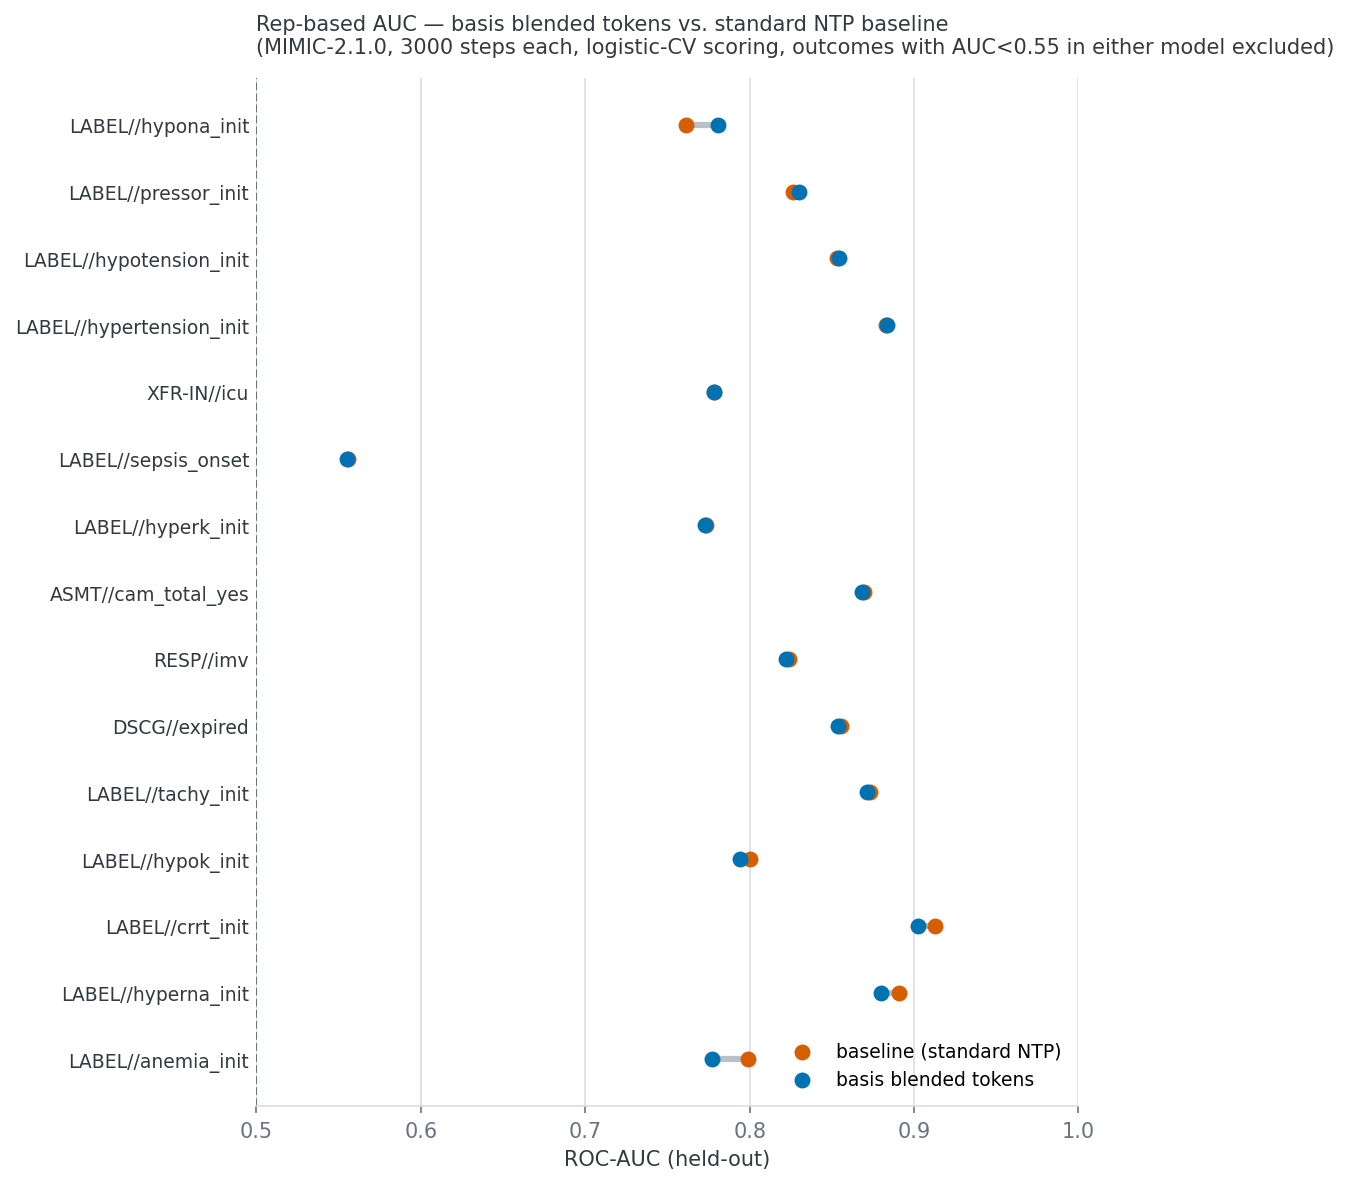

In [5]:
# dumbbell plot: two series with fixed identity (not magnitude), so a small
# fixed-order categorical pair (Okabe-Ito colorblind-safe blue/vermillion),
# never cycled, with a legend since there are 2 series.
BASIS_COLOR = "#0072B2"
BASELINE_COLOR = "#D55E00"
LINE_COLOR = "#B9C0C8"
GRID_COLOR = "#D8DEE4"
TEXT_COLOR = "#33393F"
MUTED_COLOR = "#6B7280"

labels = cmp["token"].to_list()
auc_b = cmp["auc_basis"].to_numpy()
auc_0 = cmp["auc_baseline"].to_numpy()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(labels) + 1.7), dpi=150)
ax.axvline(0.5, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.hlines(y, np.minimum(auc_b, auc_0), np.maximum(auc_b, auc_0), color=LINE_COLOR, linewidth=3, zorder=1)
ax.scatter(auc_0, y, s=44, color=BASELINE_COLOR, zorder=3, label="baseline (standard NTP)")
ax.scatter(auc_b, y, s=44, color=BASIS_COLOR, zorder=3, label="basis blended tokens")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
ax.set_xlabel("ROC-AUC (held-out)", fontsize=10, color=TEXT_COLOR)
ax.set_xlim(0.5, 1.0)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title(
    f"Rep-based AUC — basis blended tokens vs. standard NTP baseline\n"
    f"(MIMIC-2.1.0, 3000 steps each, logistic-CV scoring, outcomes with AUC<{AUC_FLOOR} in either model excluded)",
    fontsize=10, color=TEXT_COLOR, loc="left", pad=12,
)
fig.tight_layout()
fig.savefig("basis_vs_baseline_auc.png", bbox_inches="tight")
plt.show()

## Full tuning run: uncapped, Optuna-tuned, wandb-logged

The comparison above used a fixed 3000-step (~0.67 epoch) run for both
models. This section repeats the comparison with `cotorra tune` instead of
`cotorra train`: no `max_steps` cap (a full, uncapped epoch over all 373K
training subjects per trial), a 10-trial Optuna search over `learning_rate`
and `gradient_accumulation_steps` plus one final run with the best
hyperparameters (11 full-epoch runs per model), with `report_to: wandb` so
the runs were visible live at
[wandb.ai/burkhart/cotorra](https://wandb.ai/burkhart/cotorra). Everything
else (architecture, `max_seq_len`, data, logistic-CV scoring) is identical
to the run above -- see `../basis_blended_mimic_tune/` and
`../baseline_mimic_tune/`.

In [6]:
res_basis_tune = compute_aucs("mdl-basis-blended-mimic-tune")
res_baseline_tune = compute_aucs("mdl-baseline-mimic-tune")

cmp_tune_all = (
    res_basis_tune.rename({"auc": "auc_basis", "ci_lo": "ci_lo_basis", "ci_hi": "ci_hi_basis"})
    .join(
        res_baseline_tune.rename(
            {"auc": "auc_baseline", "ci_lo": "ci_lo_baseline", "ci_hi": "ci_hi_baseline"}
        ),
        on="token",
    )
    .with_columns((pl.col("auc_basis") - pl.col("auc_baseline")).alias("delta"))
)
dropped_tune = cmp_tune_all.filter(
    (pl.col("auc_basis") < AUC_FLOOR) | (pl.col("auc_baseline") < AUC_FLOOR)
)
cmp_tune = cmp_tune_all.filter(
    (pl.col("auc_basis") >= AUC_FLOOR) & (pl.col("auc_baseline") >= AUC_FLOOR)
).sort("delta", descending=True)

print(f"dropped {dropped_tune.shape[0]} outcome(s) with AUC < {AUC_FLOOR} in either model:", dropped_tune["token"].to_list())
print(f"mean delta (basis - baseline), {cmp_tune.shape[0]} outcomes: {cmp_tune['delta'].mean():+.4f}")
print(f"basis better on {(cmp_tune['delta'] > 0).sum()}/{cmp_tune.shape[0]} outcomes")
cmp_tune

dropped 0 outcome(s) with AUC < 0.55 in either model: []
mean delta (basis - baseline), 15 outcomes: +0.0077
basis better on 14/15 outcomes


token,auc_basis,ci_lo_basis,ci_hi_basis,auc_baseline,ci_lo_baseline,ci_hi_baseline,delta
str,f64,f64,f64,f64,f64,f64,f64
"""XFR-IN//icu""",0.819547,0.812933,0.825863,0.802551,0.795708,0.809564,0.016996
"""LABEL//pressor_init""",0.866723,0.859753,0.873624,0.851318,0.843454,0.859033,0.015405
"""RESP//imv""",0.855051,0.847756,0.861994,0.843307,0.835647,0.850533,0.011745
"""LABEL//hypotension_init""",0.881472,0.876804,0.886212,0.870947,0.86598,0.875849,0.010525
"""LABEL//anemia_init""",0.835618,0.829398,0.841276,0.825963,0.820228,0.83183,0.009655
…,…,…,…,…,…,…,…
"""LABEL//tachy_init""",0.886369,0.879866,0.892975,0.880444,0.873665,0.887425,0.005925
"""LABEL//crrt_init""",0.92395,0.912588,0.935502,0.91805,0.906556,0.929982,0.0059
"""LABEL//hyperk_init""",0.785814,0.772,0.799412,0.780301,0.766154,0.793385,0.005513


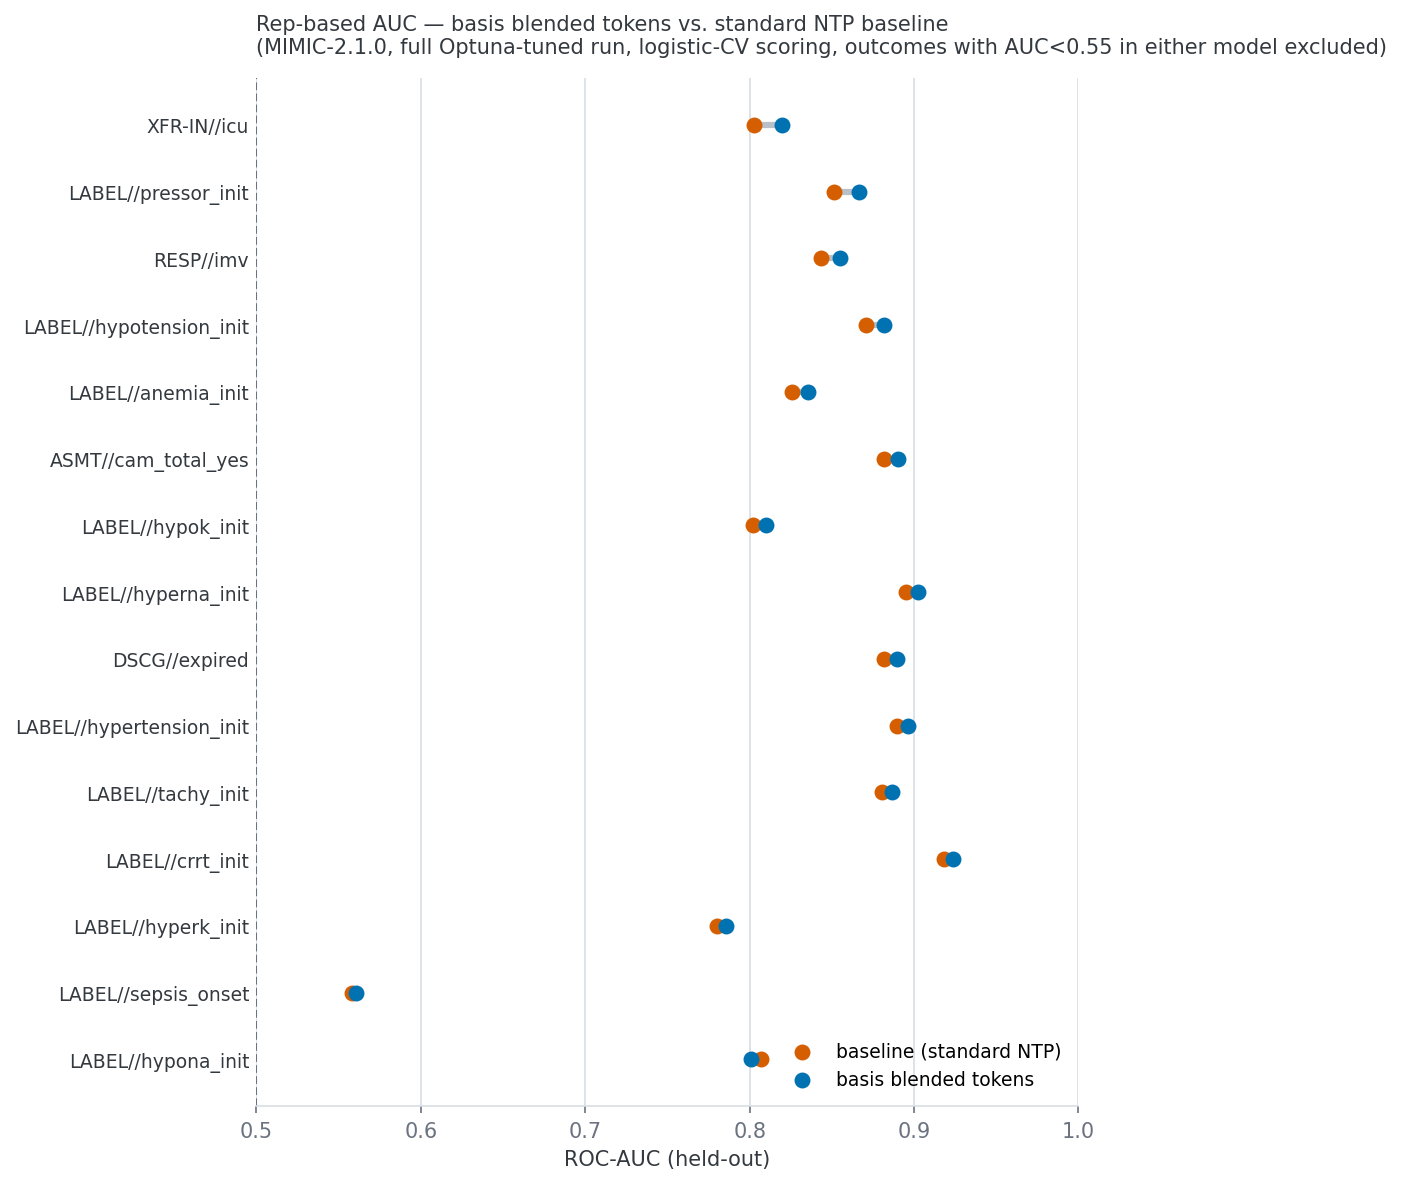

In [7]:
labels = cmp_tune["token"].to_list()
auc_b = cmp_tune["auc_basis"].to_numpy()
auc_0 = cmp_tune["auc_baseline"].to_numpy()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(labels) + 1.7), dpi=150)
ax.axvline(0.5, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.hlines(y, np.minimum(auc_b, auc_0), np.maximum(auc_b, auc_0), color=LINE_COLOR, linewidth=3, zorder=1)
ax.scatter(auc_0, y, s=44, color=BASELINE_COLOR, zorder=3, label="baseline (standard NTP)")
ax.scatter(auc_b, y, s=44, color=BASIS_COLOR, zorder=3, label="basis blended tokens")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
ax.set_xlabel("ROC-AUC (held-out)", fontsize=10, color=TEXT_COLOR)
ax.set_xlim(0.5, 1.0)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title(
    f"Rep-based AUC — basis blended tokens vs. standard NTP baseline\n"
    f"(MIMIC-2.1.0, full Optuna-tuned run, logistic-CV scoring, outcomes with AUC<{AUC_FLOOR} in either model excluded)",
    fontsize=10, color=TEXT_COLOR, loc="left", pad=12,
)
fig.tight_layout()
fig.savefig("basis_vs_baseline_auc_tuned.png", bbox_inches="tight")
plt.show()

## k=20 + trained importance scaling

Two changes on top of the tuned run above, tried together (see
`fuzzy_token_planning.md`'s "Extension" note): `k` raised from 8 to 20 basis
elements per category, and a trained per-basis importance scale `a_c,i`
added to the mixture weight formula (`w_c,i = a_c,i*f(r,i) / sum_j
a_c,j*f(r,j)`, instead of the plain density ratio), initialized to `a=1`
uniformly. Same full-tuning setup (Optuna, wandb, uncapped epoch) as the
`k=8` run above -- see `../basis_blended_mimic_tune_k20imp/`. Compared
against the *same* baseline run from above (unchanged, so not re-run).

In [8]:
res_k20imp = compute_aucs("mdl-basis-blended-mimic-tune-k20imp")

cmp_k20imp_all = (
    res_k20imp.rename({"auc": "auc_basis", "ci_lo": "ci_lo_basis", "ci_hi": "ci_hi_basis"})
    .join(
        res_baseline_tune.rename(
            {"auc": "auc_baseline", "ci_lo": "ci_lo_baseline", "ci_hi": "ci_hi_baseline"}
        ),
        on="token",
    )
    .with_columns((pl.col("auc_basis") - pl.col("auc_baseline")).alias("delta"))
)
dropped_k20imp = cmp_k20imp_all.filter(
    (pl.col("auc_basis") < AUC_FLOOR) | (pl.col("auc_baseline") < AUC_FLOOR)
)
cmp_k20imp = cmp_k20imp_all.filter(
    (pl.col("auc_basis") >= AUC_FLOOR) & (pl.col("auc_baseline") >= AUC_FLOOR)
).sort("delta", descending=True)

print(f"dropped {dropped_k20imp.shape[0]} outcome(s) with AUC < {AUC_FLOOR} in either model:", dropped_k20imp["token"].to_list())
print(f"vs. baseline -- mean delta, {cmp_k20imp.shape[0]} outcomes: {cmp_k20imp['delta'].mean():+.4f}, basis better on {(cmp_k20imp['delta'] > 0).sum()}/{cmp_k20imp.shape[0]}")

# also compare directly against the k=8 tuned basis-blended run, to see
# whether these two changes moved the method itself, not just vs. baseline
k20_vs_k8 = res_k20imp.rename({"auc": "auc_k20imp"}).join(
    res_basis_tune.rename({"auc": "auc_k8"}), on="token"
).with_columns((pl.col("auc_k20imp") - pl.col("auc_k8")).alias("delta_k20_vs_k8"))
print(f"vs. k=8 tuned basis -- mean delta: {k20_vs_k8['delta_k20_vs_k8'].mean():+.4f}, k20imp better on {(k20_vs_k8['delta_k20_vs_k8'] > 0).sum()}/{k20_vs_k8.shape[0]}")

cmp_k20imp

dropped 0 outcome(s) with AUC < 0.55 in either model: []
vs. baseline -- mean delta, 15 outcomes: +0.0012, basis better on 10/15
vs. k=8 tuned basis -- mean delta: -0.0065, k20imp better on 1/15


token,auc_basis,ci_lo_basis,ci_hi_basis,auc_baseline,ci_lo_baseline,ci_hi_baseline,delta
str,f64,f64,f64,f64,f64,f64,f64
"""LABEL//hypona_init""",0.817934,0.79203,0.843015,0.80697,0.779507,0.833359,0.010965
"""LABEL//hyperna_init""",0.900743,0.862985,0.932535,0.895012,0.858031,0.929741,0.005731
"""DSCG//expired""",0.887212,0.879498,0.894675,0.882017,0.874471,0.889332,0.005195
"""LABEL//crrt_init""",0.92086,0.908694,0.93278,0.91805,0.906556,0.929982,0.00281
"""XFR-IN//icu""",0.804301,0.7975,0.811327,0.802551,0.795708,0.809564,0.00175
…,…,…,…,…,…,…,…
"""LABEL//pressor_init""",0.850956,0.843505,0.858399,0.851318,0.843454,0.859033,-0.000362
"""RESP//imv""",0.842813,0.835349,0.850367,0.843307,0.835647,0.850533,-0.000493
"""LABEL//anemia_init""",0.825112,0.819049,0.831211,0.825963,0.820228,0.83183,-0.000851


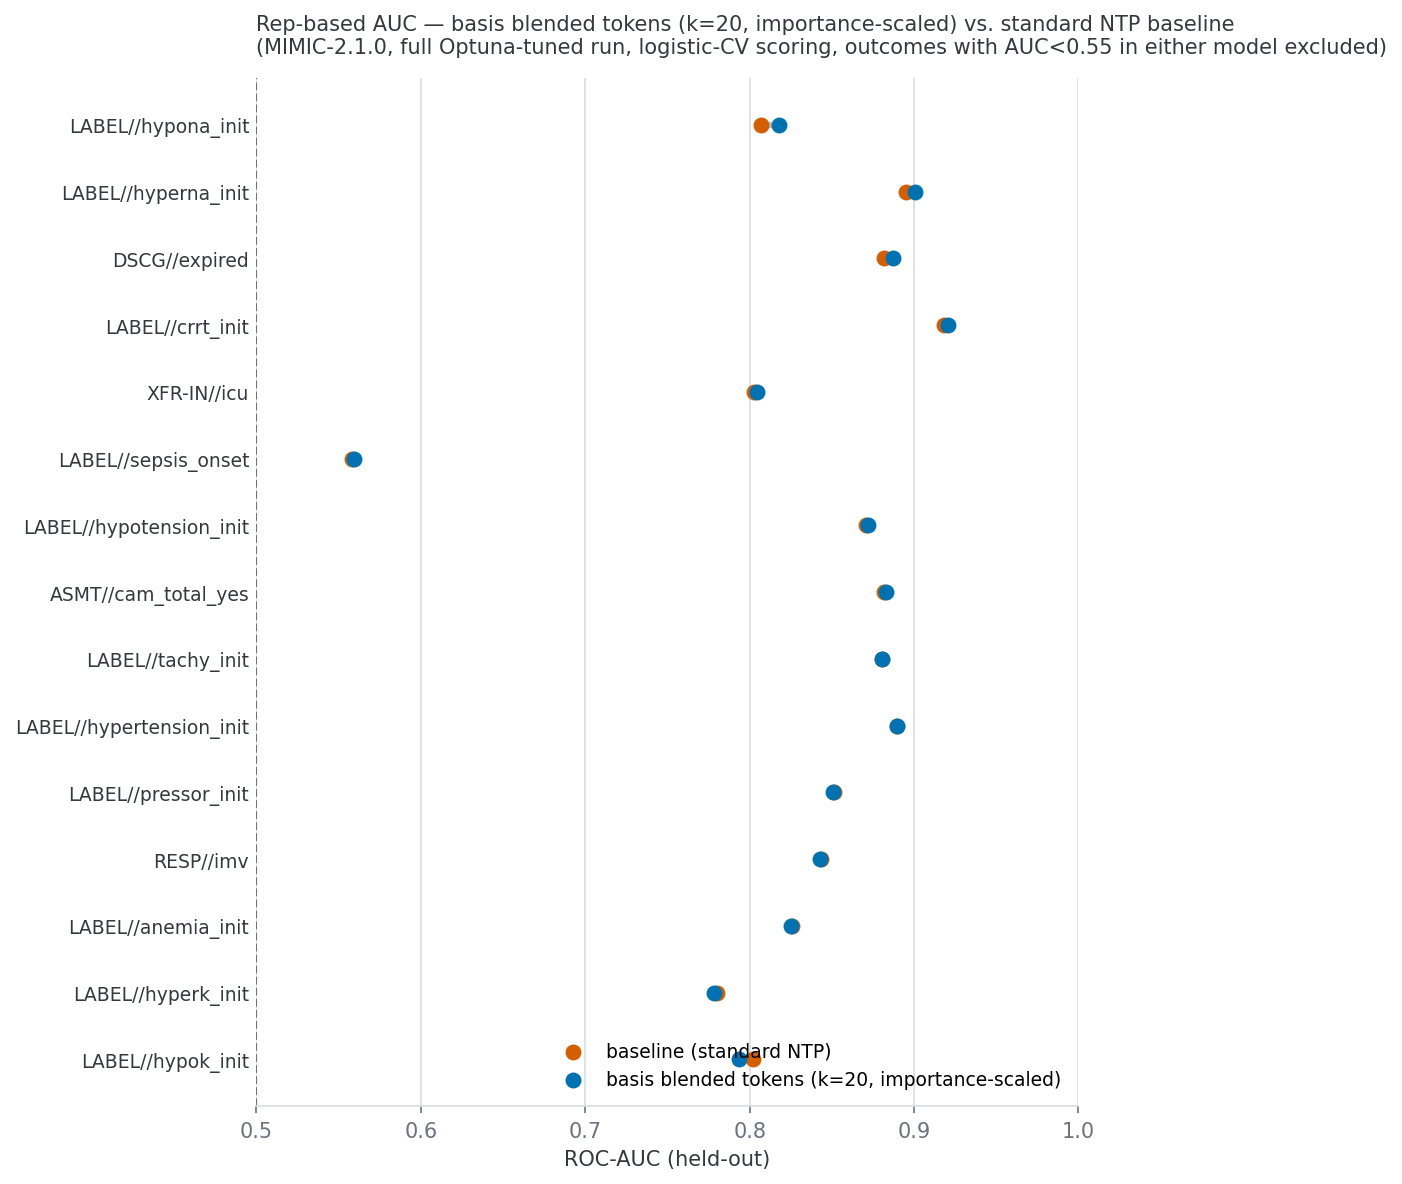

In [9]:
labels = cmp_k20imp["token"].to_list()
auc_b = cmp_k20imp["auc_basis"].to_numpy()
auc_0 = cmp_k20imp["auc_baseline"].to_numpy()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(labels) + 1.7), dpi=150)
ax.axvline(0.5, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.hlines(y, np.minimum(auc_b, auc_0), np.maximum(auc_b, auc_0), color=LINE_COLOR, linewidth=3, zorder=1)
ax.scatter(auc_0, y, s=44, color=BASELINE_COLOR, zorder=3, label="baseline (standard NTP)")
ax.scatter(auc_b, y, s=44, color=BASIS_COLOR, zorder=3, label="basis blended tokens (k=20, importance-scaled)")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
ax.set_xlabel("ROC-AUC (held-out)", fontsize=10, color=TEXT_COLOR)
ax.set_xlim(0.5, 1.0)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title(
    f"Rep-based AUC — basis blended tokens (k=20, importance-scaled) vs. standard NTP baseline\n"
    f"(MIMIC-2.1.0, full Optuna-tuned run, logistic-CV scoring, outcomes with AUC<{AUC_FLOOR} in either model excluded)",
    fontsize=10, color=TEXT_COLOR, loc="left", pad=12,
)
fig.tight_layout()
fig.savefig("basis_vs_baseline_auc_k20imp.png", bbox_inches="tight")
plt.show()

### What did the importance parameter actually learn?

`a_c,i = exp(log_importance_c,i)` for the `VTL//heart_rate` category (`a=1`
for every `i` at initialization -- no reweighting). If training left these
near 1, the parameter would be doing nothing; a wide spread means the model
found real differences in how much weight each basis element's shape should
get, independent of where that shape peaks.

Loading weights:   0%|          | 0/60 [00:00<?, ?it/s]

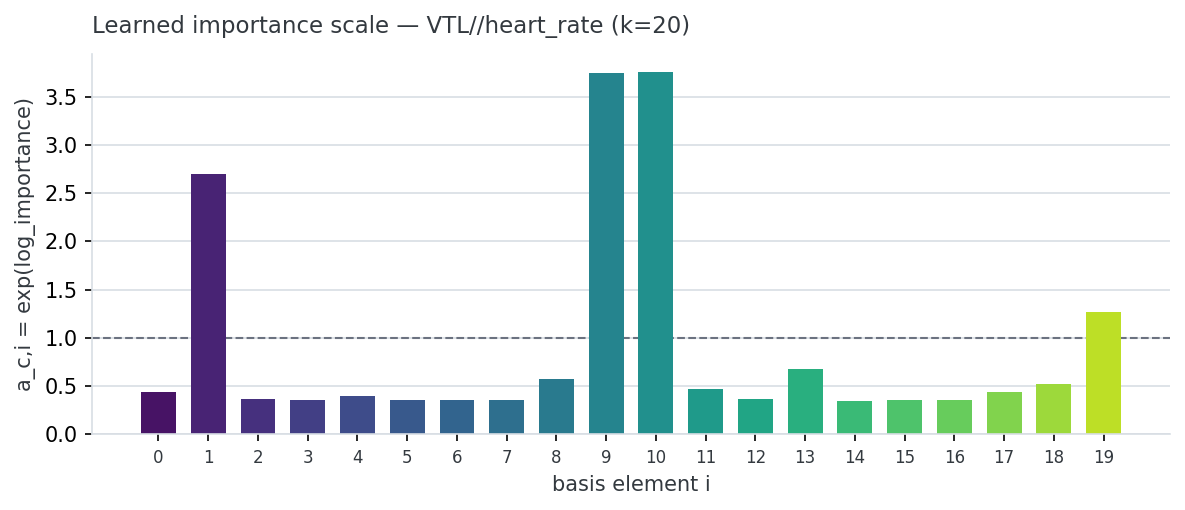

a range: [0.342, 3.760], mean 0.908


In [10]:
from transformers import AutoModelForCausalLM

from cotorra.basis_blended import BasisBlendedConfig  # noqa: F401 -- registers Auto* class

CATEGORY = "VTL//heart_rate_"
K20IMP_MODEL_HOME = (
    pathlib.Path.home()
    / "final_cotorra/cotorra/experiments/basis_blended_mimic_tune_k20imp/output/mdl-basis-blended-mimic-tune-k20imp"
)
model_k20imp = AutoModelForCausalLM.from_pretrained(K20IMP_MODEL_HOME).eval()
k20 = model_k20imp.config.k
cat_idx_20 = model_k20imp.config.categories.index(CATEGORY)
a_c = model_k20imp.log_importance[cat_idx_20].exp().detach().numpy()

cmap = plt.get_cmap("viridis")
colors20 = [cmap(x) for x in np.linspace(0.05, 0.9, k20)]
fig, ax = plt.subplots(figsize=(8, 3.5), dpi=150)
ax.axhline(1.0, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.bar(np.arange(k20), a_c, color=colors20, width=0.7, zorder=2)
ax.set_xticks(np.arange(k20))
ax.set_xticklabels([str(i) for i in range(k20)], fontsize=8, color=TEXT_COLOR)
ax.set_xlabel("basis element i", fontsize=10, color=TEXT_COLOR)
ax.set_ylabel("a_c,i = exp(log_importance)", fontsize=10, color=TEXT_COLOR)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.spines["left"].set_color(GRID_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_title(
    f"Learned importance scale — {CATEGORY.rstrip('_')} (k={k20})",
    fontsize=11, color=TEXT_COLOR, loc="left", pad=10,
)
fig.tight_layout()
fig.savefig("importance_scale_heart_rate.png", bbox_inches="tight")
plt.show()

print(f"a range: [{a_c.min():.3f}, {a_c.max():.3f}], mean {a_c.mean():.3f}")

## k=20 alone, importance scaling off

The combined k=20 + importance-scaling run above underperformed even the
plain k=8 tuned model. One hypothesis: `a_c,i` is rank-*independent*, so a
large enough `a_c,i0` for one basis element can dominate the softmax for
*every* rank simultaneously -- collapsing the blend toward one basis
regardless of the actual input, which is exactly the failure mode the
embedding tie was designed to prevent (see "Additional Clarification
Regarding Embedding Ties" in `fuzzy_token_planning.md`). This isolates `k`
from that risk: same `k=20`, `train_importance_scale: false` (`log_importance`
frozen at 0, i.e. the plain unscaled formula throughout training) -- see
`../basis_blended_mimic_tune_k20/`.

In [11]:
res_k20 = compute_aucs("mdl-basis-blended-mimic-tune-k20")

cmp_k20_all = (
    res_k20.rename({"auc": "auc_basis", "ci_lo": "ci_lo_basis", "ci_hi": "ci_hi_basis"})
    .join(
        res_baseline_tune.rename(
            {"auc": "auc_baseline", "ci_lo": "ci_lo_baseline", "ci_hi": "ci_hi_baseline"}
        ),
        on="token",
    )
    .with_columns((pl.col("auc_basis") - pl.col("auc_baseline")).alias("delta"))
)
dropped_k20 = cmp_k20_all.filter(
    (pl.col("auc_basis") < AUC_FLOOR) | (pl.col("auc_baseline") < AUC_FLOOR)
)
cmp_k20 = cmp_k20_all.filter(
    (pl.col("auc_basis") >= AUC_FLOOR) & (pl.col("auc_baseline") >= AUC_FLOOR)
).sort("delta", descending=True)

print(f"dropped {dropped_k20.shape[0]} outcome(s) with AUC < {AUC_FLOOR} in either model:", dropped_k20["token"].to_list())
print(f"vs. baseline -- mean delta, {cmp_k20.shape[0]} outcomes: {cmp_k20['delta'].mean():+.4f}, basis better on {(cmp_k20['delta'] > 0).sum()}/{cmp_k20.shape[0]}")

k20_vs_k8_plain = res_k20.rename({"auc": "auc_k20"}).join(
    res_basis_tune.rename({"auc": "auc_k8"}), on="token"
).with_columns((pl.col("auc_k20") - pl.col("auc_k8")).alias("delta_k20_vs_k8"))
print(f"vs. k=8 tuned basis -- mean delta: {k20_vs_k8_plain['delta_k20_vs_k8'].mean():+.4f}, k20 better on {(k20_vs_k8_plain['delta_k20_vs_k8'] > 0).sum()}/{k20_vs_k8_plain.shape[0]}")

k20_vs_k20imp = res_k20.rename({"auc": "auc_k20"}).join(
    res_k20imp.rename({"auc": "auc_k20imp"}), on="token"
).with_columns((pl.col("auc_k20") - pl.col("auc_k20imp")).alias("delta_k20_vs_k20imp"))
print(f"vs. k=20+importance -- mean delta: {k20_vs_k20imp['delta_k20_vs_k20imp'].mean():+.4f}, k20 (no importance) better on {(k20_vs_k20imp['delta_k20_vs_k20imp'] > 0).sum()}/{k20_vs_k20imp.shape[0]}")

cmp_k20

dropped 0 outcome(s) with AUC < 0.55 in either model: []
vs. baseline -- mean delta, 15 outcomes: +0.0017, basis better on 8/15
vs. k=8 tuned basis -- mean delta: -0.0060, k20 better on 2/15
vs. k=20+importance -- mean delta: +0.0005, k20 (no importance) better on 4/15


token,auc_basis,ci_lo_basis,ci_hi_basis,auc_baseline,ci_lo_baseline,ci_hi_baseline,delta
str,f64,f64,f64,f64,f64,f64,f64
"""LABEL//hypok_init""",0.816074,0.790918,0.84137,0.801864,0.774695,0.82869,0.01421
"""LABEL//hypona_init""",0.812281,0.78522,0.838526,0.80697,0.779507,0.833359,0.005312
"""LABEL//crrt_init""",0.923301,0.911171,0.935398,0.91805,0.906556,0.929982,0.005251
"""LABEL//hyperna_init""",0.899817,0.862956,0.931285,0.895012,0.858031,0.929741,0.004804
"""LABEL//hyperk_init""",0.784789,0.770715,0.798313,0.780301,0.766154,0.793385,0.004488
…,…,…,…,…,…,…,…
"""LABEL//hypertension_init""",0.888381,0.882427,0.894415,0.889524,0.88386,0.895371,-0.001143
"""XFR-IN//icu""",0.800629,0.793885,0.807411,0.802551,0.795708,0.809564,-0.001922
"""LABEL//tachy_init""",0.878467,0.870924,0.885481,0.880444,0.873665,0.887425,-0.001977


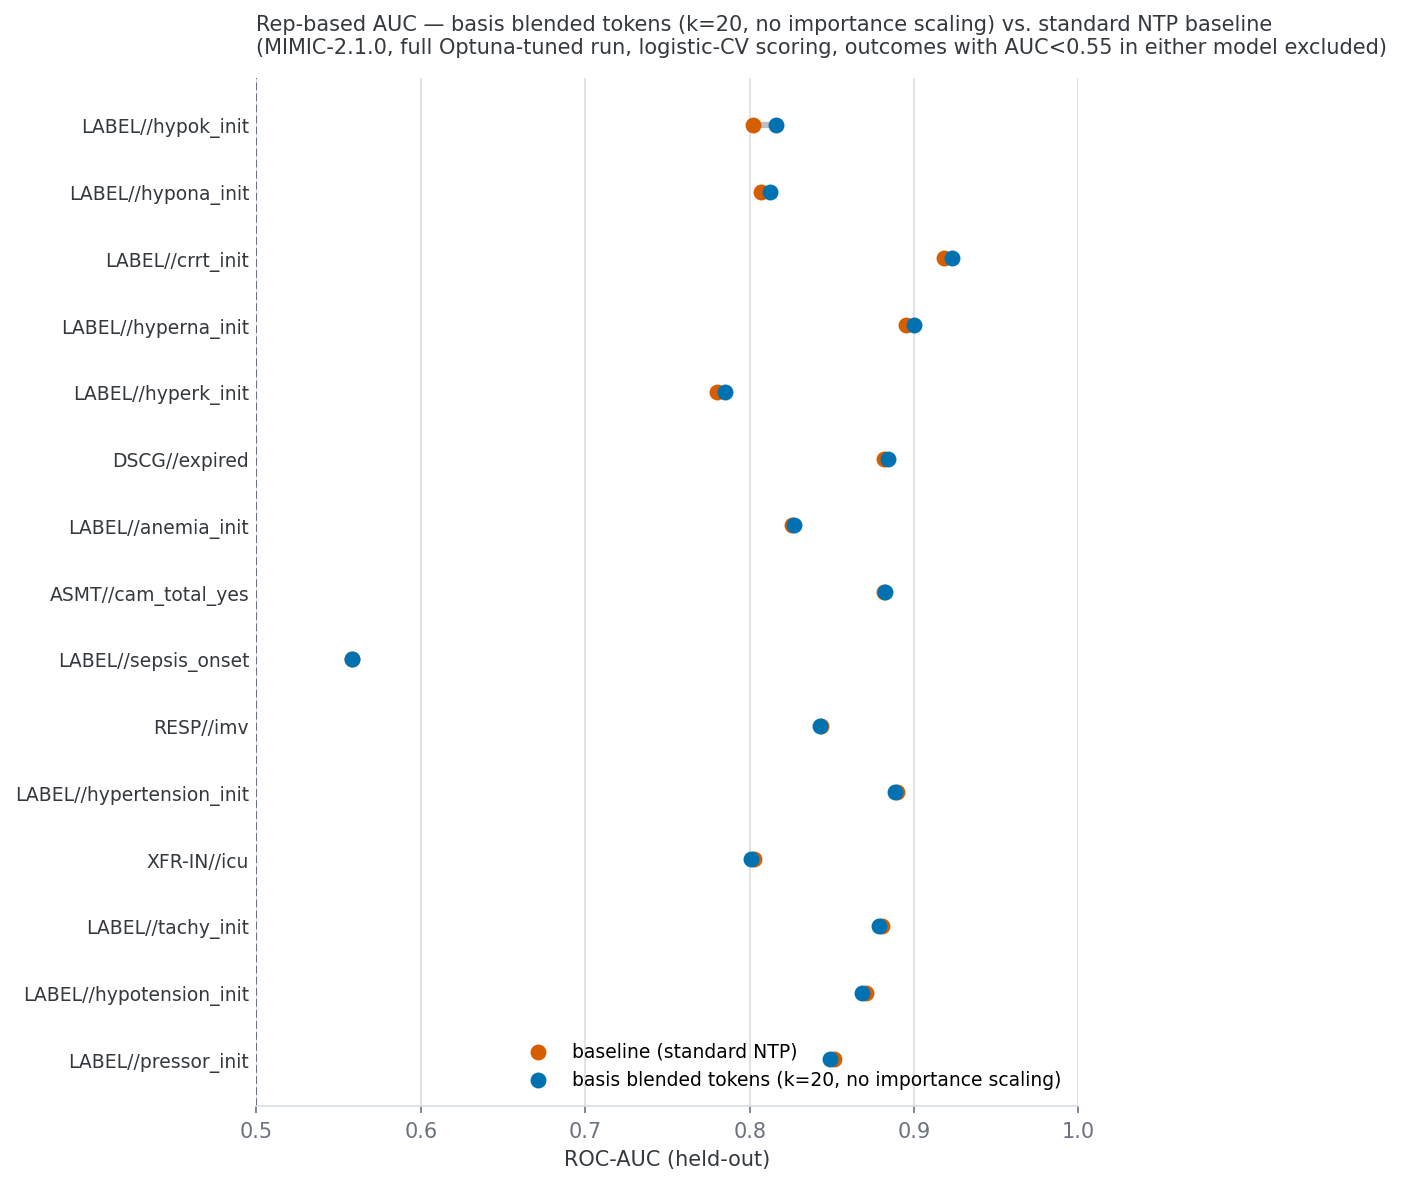

In [12]:
labels = cmp_k20["token"].to_list()
auc_b = cmp_k20["auc_basis"].to_numpy()
auc_0 = cmp_k20["auc_baseline"].to_numpy()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(labels) + 1.7), dpi=150)
ax.axvline(0.5, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.hlines(y, np.minimum(auc_b, auc_0), np.maximum(auc_b, auc_0), color=LINE_COLOR, linewidth=3, zorder=1)
ax.scatter(auc_0, y, s=44, color=BASELINE_COLOR, zorder=3, label="baseline (standard NTP)")
ax.scatter(auc_b, y, s=44, color=BASIS_COLOR, zorder=3, label="basis blended tokens (k=20, no importance scaling)")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
ax.set_xlabel("ROC-AUC (held-out)", fontsize=10, color=TEXT_COLOR)
ax.set_xlim(0.5, 1.0)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title(
    f"Rep-based AUC — basis blended tokens (k=20, no importance scaling) vs. standard NTP baseline\n"
    f"(MIMIC-2.1.0, full Optuna-tuned run, logistic-CV scoring, outcomes with AUC<{AUC_FLOOR} in either model excluded)",
    fontsize=10, color=TEXT_COLOR, loc="left", pad=12,
)
fig.tight_layout()
fig.savefig("basis_vs_baseline_auc_k20.png", bbox_inches="tight")
plt.show()

## k=8, fully frozen (fixed order-statistic blend)

Neither the `k=20+importance` nor the `k=20` run beat the plain `k=8` tuned
model, so the natural next question is the opposite direction: how much of
the `k=8` result comes from *learning* the Beta shapes/importances at all,
versus just from having `k` fixed order-statistic basis elements per
category to blend between? This run matches `k=8` exactly but sets
`train_beta_params: false` *and* `train_importance_scale: false`, so
`log_alpha`/`log_beta` stay frozen at their shared order-statistic init and
`log_importance` stays frozen at 0 (`a=1` uniformly) for the entire run --
only `e_c,i` (and the rest of the transformer) actually train, `w_c,i(r)` is
a fixed function of rank throughout -- see
`../basis_blended_mimic_tune_k8frozen/`.

In [13]:
res_k8frozen = compute_aucs("mdl-basis-blended-mimic-tune-k8frozen")

cmp_k8frozen_all = (
    res_k8frozen.rename({"auc": "auc_basis", "ci_lo": "ci_lo_basis", "ci_hi": "ci_hi_basis"})
    .join(
        res_baseline_tune.rename(
            {"auc": "auc_baseline", "ci_lo": "ci_lo_baseline", "ci_hi": "ci_hi_baseline"}
        ),
        on="token",
    )
    .with_columns((pl.col("auc_basis") - pl.col("auc_baseline")).alias("delta"))
)
dropped_k8frozen = cmp_k8frozen_all.filter(
    (pl.col("auc_basis") < AUC_FLOOR) | (pl.col("auc_baseline") < AUC_FLOOR)
)
cmp_k8frozen = cmp_k8frozen_all.filter(
    (pl.col("auc_basis") >= AUC_FLOOR) & (pl.col("auc_baseline") >= AUC_FLOOR)
).sort("delta", descending=True)

print(f"dropped {dropped_k8frozen.shape[0]} outcome(s) with AUC < {AUC_FLOOR} in either model:", dropped_k8frozen["token"].to_list())
print(f"vs. baseline -- mean delta, {cmp_k8frozen.shape[0]} outcomes: {cmp_k8frozen['delta'].mean():+.4f}, basis better on {(cmp_k8frozen['delta'] > 0).sum()}/{cmp_k8frozen.shape[0]}")

k8frozen_vs_k8 = res_k8frozen.rename({"auc": "auc_k8frozen"}).join(
    res_basis_tune.rename({"auc": "auc_k8"}), on="token"
).with_columns((pl.col("auc_k8frozen") - pl.col("auc_k8")).alias("delta_k8frozen_vs_k8"))
print(f"vs. k=8 tuned (trainable) basis -- mean delta: {k8frozen_vs_k8['delta_k8frozen_vs_k8'].mean():+.4f}, frozen better on {(k8frozen_vs_k8['delta_k8frozen_vs_k8'] > 0).sum()}/{k8frozen_vs_k8.shape[0]}")

cmp_k8frozen

dropped 0 outcome(s) with AUC < 0.55 in either model: []
vs. baseline -- mean delta, 15 outcomes: +0.0066, basis better on 14/15
vs. k=8 tuned (trainable) basis -- mean delta: -0.0011, frozen better on 6/15


token,auc_basis,ci_lo_basis,ci_hi_basis,auc_baseline,ci_lo_baseline,ci_hi_baseline,delta
str,f64,f64,f64,f64,f64,f64,f64
"""LABEL//hypok_init""",0.815058,0.788386,0.840093,0.801864,0.774695,0.82869,0.013195
"""XFR-IN//icu""",0.815257,0.808761,0.821792,0.802551,0.795708,0.809564,0.012706
"""LABEL//anemia_init""",0.837182,0.830955,0.84297,0.825963,0.820228,0.83183,0.011219
"""DSCG//expired""",0.892948,0.885911,0.899968,0.882017,0.874471,0.889332,0.010931
"""RESP//imv""",0.852895,0.84583,0.860258,0.843307,0.835647,0.850533,0.009588
…,…,…,…,…,…,…,…
"""LABEL//hypertension_init""",0.894876,0.889385,0.900114,0.889524,0.88386,0.895371,0.005352
"""LABEL//tachy_init""",0.884891,0.878091,0.891504,0.880444,0.873665,0.887425,0.004447
"""LABEL//sepsis_onset""",0.559837,0.555788,0.564133,0.5581,0.553833,0.562229,0.001738


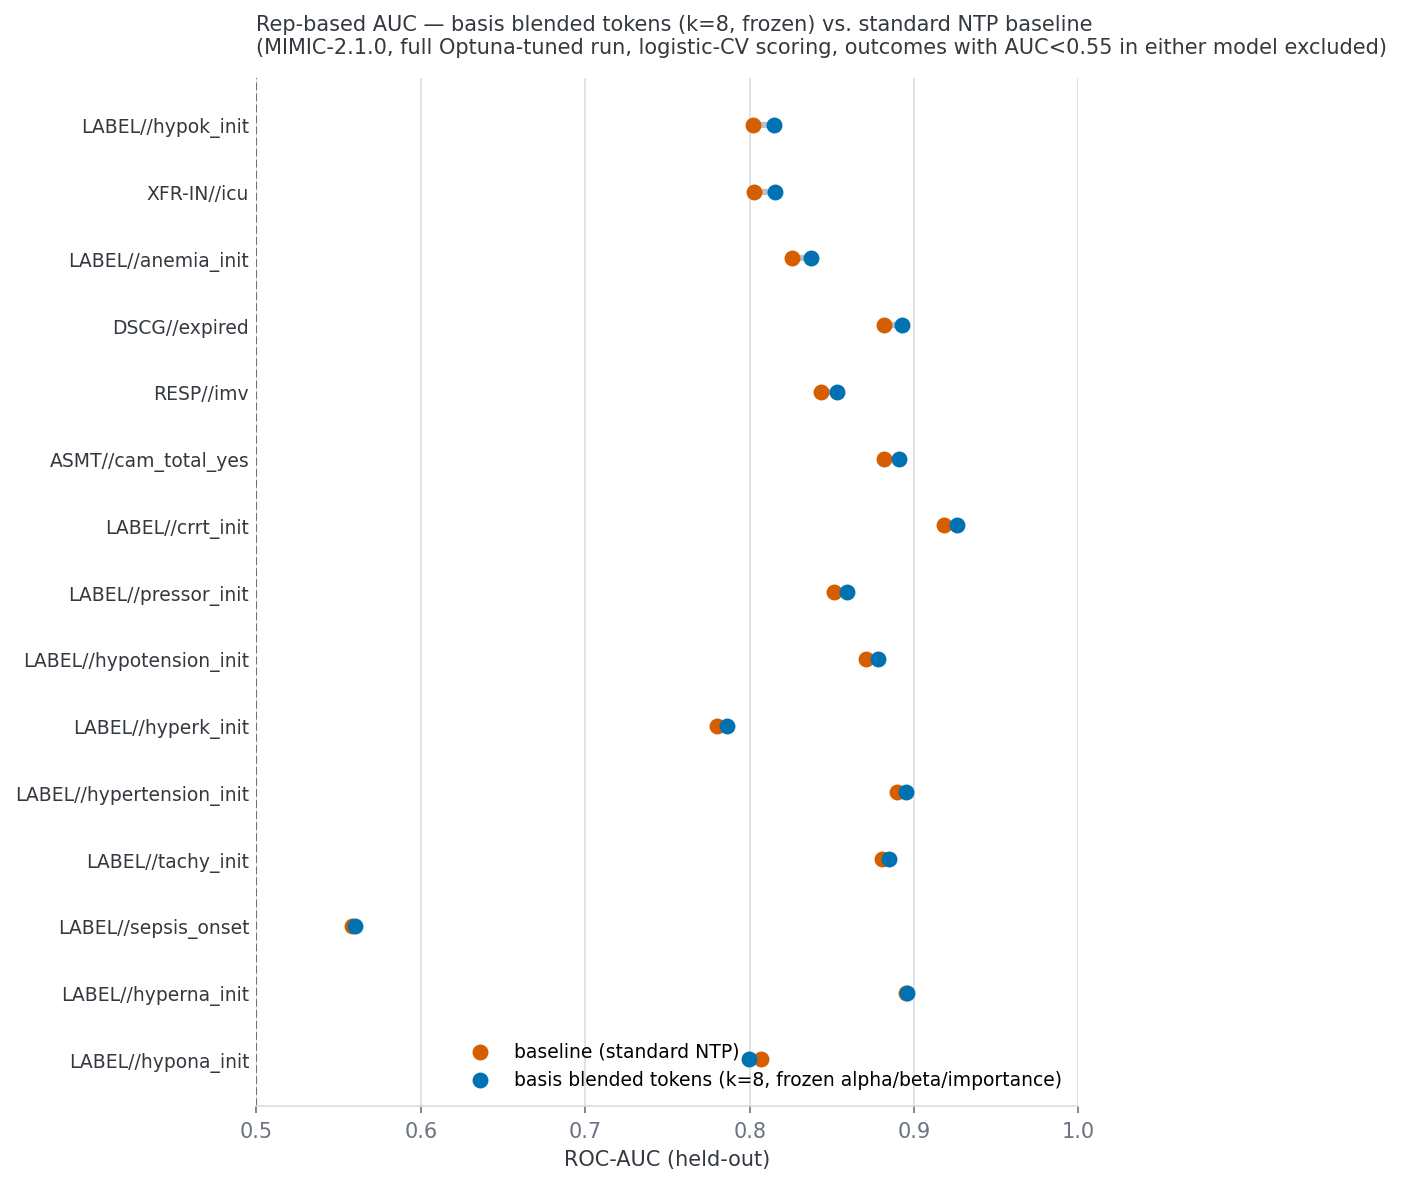

In [14]:
labels = cmp_k8frozen["token"].to_list()
auc_b = cmp_k8frozen["auc_basis"].to_numpy()
auc_0 = cmp_k8frozen["auc_baseline"].to_numpy()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(labels) + 1.7), dpi=150)
ax.axvline(0.5, color=MUTED_COLOR, linewidth=1, linestyle="--", zorder=1)
ax.hlines(y, np.minimum(auc_b, auc_0), np.maximum(auc_b, auc_0), color=LINE_COLOR, linewidth=3, zorder=1)
ax.scatter(auc_0, y, s=44, color=BASELINE_COLOR, zorder=3, label="baseline (standard NTP)")
ax.scatter(auc_b, y, s=44, color=BASIS_COLOR, zorder=3, label="basis blended tokens (k=8, frozen alpha/beta/importance)")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
ax.set_xlabel("ROC-AUC (held-out)", fontsize=10, color=TEXT_COLOR)
ax.set_xlim(0.5, 1.0)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title(
    f"Rep-based AUC — basis blended tokens (k=8, frozen) vs. standard NTP baseline\n"
    f"(MIMIC-2.1.0, full Optuna-tuned run, logistic-CV scoring, outcomes with AUC<{AUC_FLOOR} in either model excluded)",
    fontsize=10, color=TEXT_COLOR, loc="left", pad=12,
)
fig.tight_layout()
fig.savefig("basis_vs_baseline_auc_k8frozen.png", bbox_inches="tight")
plt.show()

## Beta basis components: initialization vs. trained (heart rate)

Each numeric category gets `k` basis elements `(e_i, P_i)`, with `P_i` a
`Beta(alpha_i, beta_i)` initialized at the `i`-th order statistic of `k`
draws from Uniform[0,1] (`log(alpha_i) = log(i+1)`, `log(beta_i) = log(k-i)`
in 0-indexed form) -- identical across every category at init. With
`train_beta_params: true`, `log(alpha)`/`log(beta)` receive gradient, so a
category's `k` components can reshape themselves away from that shared
starting point based on the actual rank distribution of its measurements.
This compares the initialization against the trained `VTL//heart_rate`
category to check that something real happened, not just numerical drift.

In [15]:
from scipy.stats import beta as beta_dist
from transformers import AutoModelForCausalLM

from cotorra.basis_blended import BasisBlendedConfig  # noqa: F401 -- registers Auto* class

MODEL_HOME = (
    pathlib.Path.home()
    / "final_cotorra/cotorra/experiments/basis_blended_mimic_tune/output/mdl-basis-blended-mimic-tune"
)
model = AutoModelForCausalLM.from_pretrained(MODEL_HOME).eval()

CATEGORY = "VTL//heart_rate_"
cat_idx = model.config.categories.index(CATEGORY)
k = model.config.k

idx = np.arange(k)
alpha_init, beta_init = idx + 1, k - idx  # shared order-statistic init, every category
alpha_final = model.log_alpha[cat_idx].exp().detach().numpy()
beta_final = model.log_beta[cat_idx].exp().detach().numpy()

print("alpha: init", alpha_init, "-> trained", alpha_final.round(2))
print("beta:  init", beta_init, "-> trained", beta_final.round(2))

Loading weights:   0%|          | 0/59 [00:00<?, ?it/s]

BasisBlendedCausalLM LOAD REPORT from: /home/lsolo/final_cotorra/cotorra/experiments/basis_blended_mimic_tune/output/mdl-basis-blended-mimic-tune
Key            | Status  | 
---------------+---------+-
log_importance | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


alpha: init [1 2 3 4 5 6 7 8] -> trained [ 0.33  0.61  0.98  2.61 14.37 23.04 25.66 27.  ]
beta:  init [8 7 6 5 4 3 2 1] -> trained [27.08 25.44 23.27 13.58  2.65  0.96  0.62  0.34]


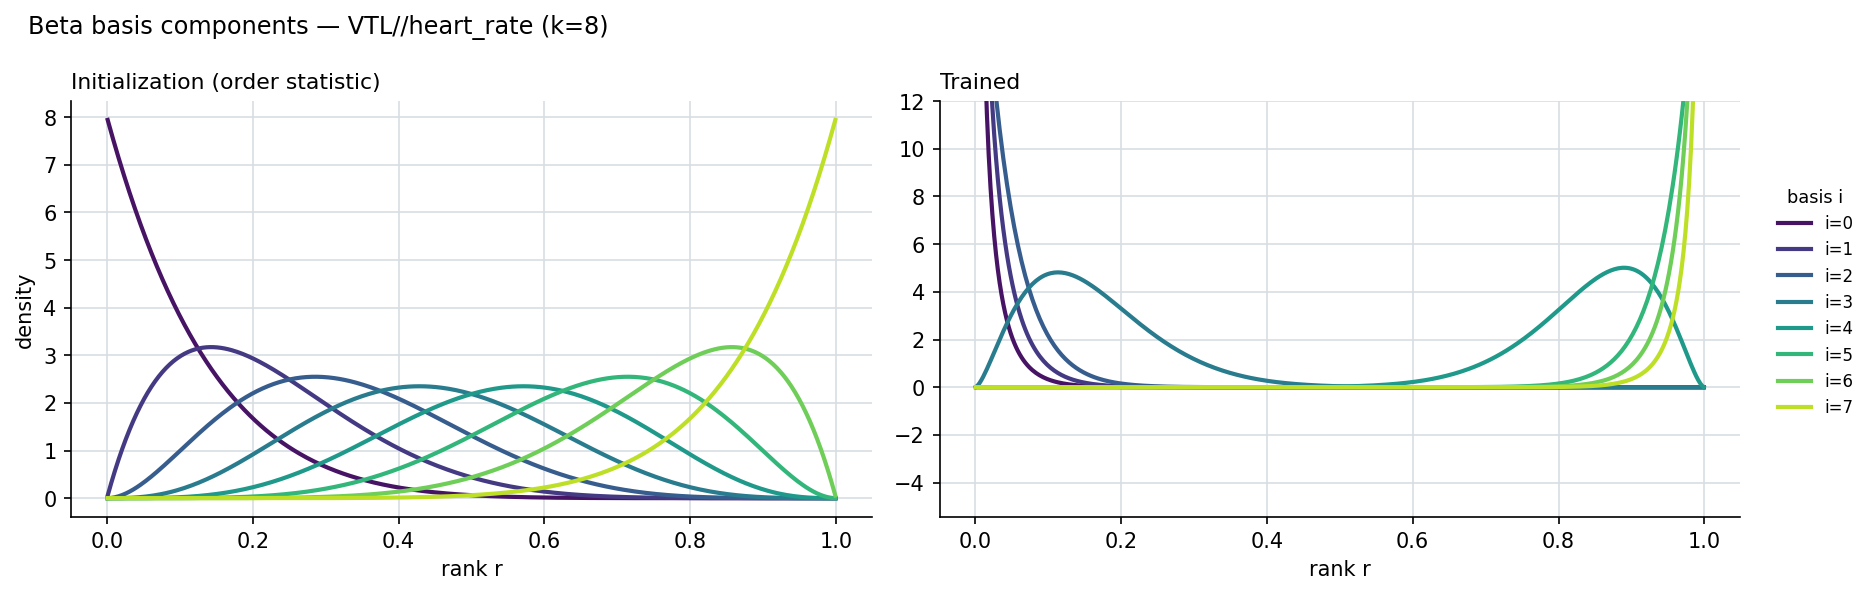

In [16]:
# k basis components have a natural order (increasing order-statistic
# position), so this is a magnitude/sequence encoding, not identity --
# one hue, light->dark, rather than a categorical palette.
r = np.linspace(1e-3, 1 - 1e-3, 400)
cmap = plt.get_cmap("viridis")
colors = [cmap(x) for x in np.linspace(0.05, 0.9, k)]
GRID_COLOR = "#D8DEE4"

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4), dpi=150, sharex=True)
lines = []
for i in range(k):
    axes[0].plot(r, beta_dist.pdf(r, alpha_init[i], beta_init[i]), color=colors[i], linewidth=2)
    (ln,) = axes[1].plot(
        r, beta_dist.pdf(r, alpha_final[i], beta_final[i]), color=colors[i], linewidth=2, label=f"i={i}"
    )
    lines.append(ln)

for ax, title in zip(axes, ("Initialization (order statistic)", "Trained")):
    ax.set_title(title, fontsize=10.5, loc="left")
    ax.set_xlabel("rank r")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)

axes[0].set_ylabel("density")
axes[1].set_ylim(top=min(axes[1].get_ylim()[1], 12))  # a near-boundary alpha/beta can spike sharply
fig.legend(
    lines, [f"i={i}" for i in range(k)], title="basis i", fontsize=8, title_fontsize=8.5,
    loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False,
)

fig.suptitle(f"Beta basis components — {CATEGORY.rstrip('_')} (k={k})", fontsize=11.5, x=0.02, ha="left")
fig.tight_layout()
fig.savefig("beta_heart_rate_init_vs_trained.png", bbox_inches="tight")
plt.show()

### 2D PCA of heart rate value embeddings

Every heart rate measurement in the training data gets embedded as
`e(c,r) = sum_i w_c,i(r) * e_c,i` -- a point in 256-dim space determined
entirely by its continuous rank `r`. Pulling the actual embedding for every
(sampled) heart rate measurement in the training set and projecting to 2D
shows whether that blend traces a smooth, rank-ordered manifold, or
something more chaotic.

In [17]:
import torch as t
from sklearn.decomposition import PCA

raw_to_category = np.array(model.config.raw_to_category)
heart_rate_raw_ids = np.where(raw_to_category == cat_idx)[0].tolist()

train_lf = pl.scan_parquet(PROCESSED / "train_tokens_times.parquet").select(
    "tokens", "exact_ranks"
)
heart_rate_ranks = (
    train_lf.explode(["tokens", "exact_ranks"])
    .filter(pl.col("tokens").is_in(heart_rate_raw_ids))
    .select("exact_ranks")
)
n_total = heart_rate_ranks.select(pl.len()).collect().item()

N_SAMPLE = 10_000
sampled_ranks = (
    heart_rate_ranks.collect()["exact_ranks"].sample(n=min(N_SAMPLE, n_total), seed=42).to_numpy()
)
finite = np.isfinite(sampled_ranks)
if not finite.all():
    print(f"dropping {(~finite).sum()} non-finite sampled rank(s)")
    sampled_ranks = sampled_ranks[finite]
print(f"{n_total:,} heart rate measurements in train split; sampled {len(sampled_ranks):,}")

# Reconstruct an approximate raw value for each sampled rank via the
# empirical quantile function of the code's raw training values (exact_rank
# is itself that empirical-CDF position, so this inverts it). cocoa was
# tokenized with include_numeric_values=false, so the raw value isn't stored
# per-token -- this recovers it from the same underlying training
# distribution instead of a per-row join.
train_subjects = pl.scan_parquet(PROCESSED / "subject_splits.parquet").filter(
    pl.col("split") == "train"
)
raw_hr_values = (
    pl.scan_parquet(PROCESSED / "meds.parquet")
    .filter(pl.col("code") == CATEGORY.rstrip("_"))
    .join(train_subjects, on="subject_id", how="inner")
    .select("numeric_value")
    .drop_nulls()
    .collect()["numeric_value"]
    .to_numpy()
)
sampled_values = np.quantile(raw_hr_values, sampled_ranks)

with t.no_grad():
    n = len(sampled_ranks)
    cat_ids_hr = t.full((1, n), cat_idx, dtype=t.long)
    ranks_hr = t.tensor(sampled_ranks, dtype=t.float32).unsqueeze(0)
    w_hr = model._mixture_weights(cat_ids_hr, ranks_hr)  # (1,n,k)
    embed = model.get_input_embeddings()
    basis_ids_hr = model.category_base_id_t[cat_ids_hr].unsqueeze(-1) + t.arange(k)  # (1,n,k)
    blended_hr = (w_hr.unsqueeze(-1) * embed(basis_ids_hr)).sum(dim=2).squeeze(0)  # (n,H)

# defensive: drop any non-finite embedding rows before PCA, whatever their cause
blended_hr_np = blended_hr.numpy()
row_finite = np.isfinite(blended_hr_np).all(axis=1)
if not row_finite.all():
    print(f"dropping {(~row_finite).sum()} non-finite embedding row(s) before PCA")
    blended_hr_np = blended_hr_np[row_finite]
    sampled_ranks = sampled_ranks[row_finite]
    sampled_values = sampled_values[row_finite]

pca = PCA(n_components=2)
coords = pca.fit_transform(blended_hr_np)
print(f"explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"corr(rank, PC1) = {np.corrcoef(sampled_ranks, coords[:, 0])[0, 1]:+.3f}")

/tmp/ipykernel_7386/2757363799.py:11: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  train_lf.explode(["tokens", "exact_ranks"])


6,122,484 heart rate measurements in train split; sampled 10,000


explained variance: PC1=74.9%, PC2=20.8%
corr(rank, PC1) = +0.940


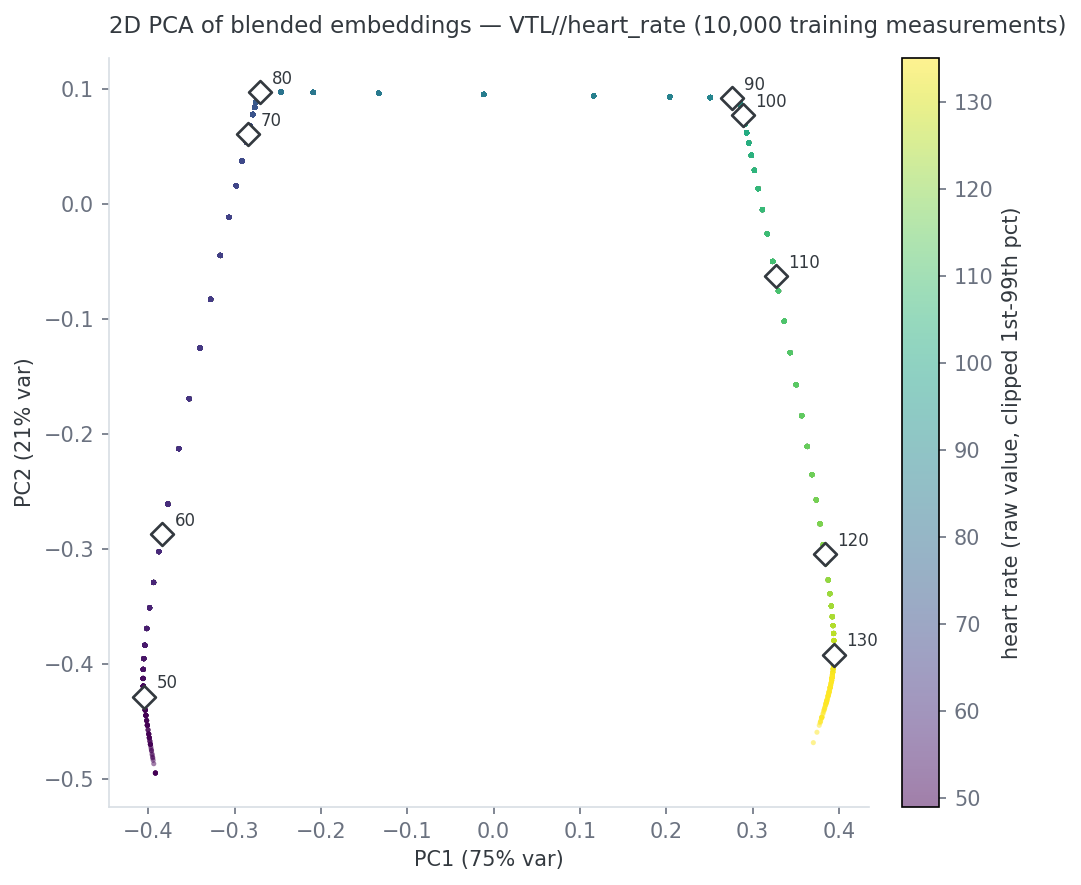

In [18]:
# COLOR_BY: "value" (raw heart rate, reconstructed -- more clinically
# interpretable) or "rank" (percentile, always cleanly in [0,1]). Either way
# this is a continuous magnitude, not an identity -- one hue, light->dark,
# with a colorbar rather than a categorical legend.
COLOR_BY = "value"  # "value" or "rank"

if COLOR_BY == "value":
    color = sampled_values
    # a couple of data-entry outliers (e.g. a -1 sentinel, a 1e7 typo) exist
    # at the extremes of this dataset's raw heart rate values; clip the
    # color scale to the sample's 1st/99th percentile so they don't wash out
    # the rest of the plot. The points themselves are still shown at their
    # true PCA position -- only the color scale is clipped.
    vmin, vmax = np.percentile(sampled_values, [1, 99])
    cbar_label = "heart rate (raw value, clipped 1st-99th pct)"
    tick_step = 10
else:
    color = sampled_ranks
    vmin, vmax = 0.0, 1.0
    cbar_label = "rank r"
    tick_step = 0.1

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
sc = ax.scatter(
    coords[:, 0], coords[:, 1], c=color, cmap="viridis", vmin=vmin, vmax=vmax,
    s=6, alpha=0.5, linewidths=0,
)
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(cbar_label, fontsize=10, color=TEXT_COLOR)
cbar.ax.tick_params(colors=MUTED_COLOR)
tick_start = np.ceil(vmin / tick_step) * tick_step
ticks = np.arange(tick_start, vmax + tick_step / 2, tick_step)
cbar.set_ticks(ticks)

# Mark *on the manifold itself* where each round increment actually falls:
# for each tick value, find its rank (inverting the empirical quantile
# function for "value" mode), get that rank's real blended embedding from
# the model, and project it through the *same fitted* PCA transform.
if COLOR_BY == "value":
    sorted_vals = np.sort(raw_hr_values)
    marker_ranks = np.searchsorted(sorted_vals, ticks) / len(sorted_vals)
else:
    marker_ranks = ticks

with t.no_grad():
    m = len(marker_ranks)
    cat_ids_mk = t.full((1, m), cat_idx, dtype=t.long)
    ranks_mk = t.tensor(marker_ranks, dtype=t.float32).unsqueeze(0)
    w_mk = model._mixture_weights(cat_ids_mk, ranks_mk)
    basis_ids_mk = model.category_base_id_t[cat_ids_mk].unsqueeze(-1) + t.arange(k)
    blended_mk = (w_mk.unsqueeze(-1) * embed(basis_ids_mk)).sum(dim=2).squeeze(0)
marker_coords = pca.transform(blended_mk.numpy())

ax.scatter(
    marker_coords[:, 0], marker_coords[:, 1], marker="D", s=60,
    facecolor="white", edgecolor=TEXT_COLOR, linewidth=1.3, zorder=5,
)
for (mx, my), val in zip(marker_coords, ticks):
    label = f"{val:.0f}" if COLOR_BY == "value" else f"{val:.1f}"
    ax.annotate(
        label, (mx, my), textcoords="offset points", xytext=(6, 4),
        fontsize=8, color=TEXT_COLOR, zorder=6,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)", fontsize=10, color=TEXT_COLOR)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)", fontsize=10, color=TEXT_COLOR)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.spines["left"].set_color(GRID_COLOR)
ax.tick_params(colors=MUTED_COLOR)
ax.set_title(
    f"2D PCA of blended embeddings — {CATEGORY.rstrip('_')} "
    f"({len(sampled_ranks):,} training measurements)",
    fontsize=11, color=TEXT_COLOR, loc="left", pad=12,
)
fig.tight_layout()
fig.savefig("heart_rate_embedding_pca.png", bbox_inches="tight")
plt.show()

## Interactive: mixture weights at a chosen rank

Pick a category and a rank `r`; left panel shows every basis element's Beta
density with `r` marked, right panel shows the resulting mixture weights
`w_c,i(r)` actually used to blend the embedding at that rank (via the
model's own `_mixture_weights`, so this includes importance scaling if the
loaded model has it). Uses the same (tuned k=8) `model` loaded above. Slider
updates on release, not while dragging.

In [19]:
import ipywidgets as widgets
from ipywidgets import interact
from scipy.stats import beta as beta_dist

_cmap = plt.get_cmap("viridis")


def plot_mixture_weights(category, r):
    ci = model.config.categories.index(category)
    kk = model.config.k
    alpha = model.log_alpha[ci].exp().detach().numpy()
    beta_shape = model.log_beta[ci].exp().detach().numpy()

    with t.no_grad():
        cat_ids = t.tensor([[ci]], dtype=t.long)
        ranks_in = t.tensor([[r]], dtype=t.float32)
        w = model._mixture_weights(cat_ids, ranks_in).squeeze().numpy()

    colors_k = [_cmap(x) for x in np.linspace(0.05, 0.9, kk)]
    grid = np.linspace(1e-3, 1 - 1e-3, 300)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=110)
    for i in range(kk):
        axes[0].plot(grid, beta_dist.pdf(grid, alpha[i], beta_shape[i]), color=colors_k[i], linewidth=1.8)
    axes[0].axvline(r, color=TEXT_COLOR, linewidth=1.2, linestyle="--")
    axes[0].set_xlabel("rank r")
    axes[0].set_ylabel("density")
    axes[0].set_title(f"Beta components — {category.rstrip('_')}", fontsize=10.5, loc="left")
    for spine in ("top", "right"):
        axes[0].spines[spine].set_visible(False)
    axes[0].grid(True, color=GRID_COLOR, linewidth=0.8)
    axes[0].set_axisbelow(True)

    axes[1].bar(np.arange(kk), w, color=colors_k, width=0.7)
    axes[1].set_xticks(np.arange(kk))
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("basis element i")
    axes[1].set_ylabel("mixture weight w_i")
    axes[1].set_title(f"w_i at r={r:.2f} (sum={w.sum():.3f})", fontsize=10.5, loc="left")
    for spine in ("top", "right"):
        axes[1].spines[spine].set_visible(False)
    axes[1].grid(True, axis="y", color=GRID_COLOR, linewidth=0.8)
    axes[1].set_axisbelow(True)

    fig.tight_layout()
    plt.show()


interact(
    plot_mixture_weights,
    category=widgets.Dropdown(
        options=model.config.categories, value=CATEGORY, description="category"
    ),
    r=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.01, value=0.5, description="rank r", continuous_update=False
    ),
);

interactive(children=(Dropdown(description='category', index=143, options=('AGE//age_', 'ASMT//braden_activity…